# spectrum cube reducing and moment_0

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import astropy.units as u
from astropy.io import fits

#from astropy.utils import data
#data.conf.remote_timeout = 60

import radio_beam
from spectral_cube import SpectralCube
from astropy.convolution import Gaussian1DKernel
from astropy.convolution import Gaussian2DKernel

from astroquery.esasky import ESASky
from astroquery.utils import TableList
from astropy.wcs import WCS
from reproject import reproject_interp
from astropy.stats import sigma_clipped_stats
from astropy.visualization.wcsaxes import WCSAxes

from regions import Regions
from specutils import Spectrum1D

import os

In [3]:
cubefile_list = [
    'ngc3351_12m+7m+tp_co10_pbcorr_trimmed_k.fits',
    'ngc3351_12m+7m+tp_co21.fits',
    'M95_C3+7m_co32_pbcorr_round_k.fits',
    'M95_C5+C2_hcn10_pbcorr_round_k.fits',
    'M95_C5+C2_cs21_pbcorr_round_k.fits',   
    'M95_C3+7m_cs76_pbcorr_round_k.fits',
    'M95_C5+C2_hcop10_pbcorr_round_k.fits',
    'M95_C3+7m_hcop43_pbcorr_round_k.fits',
]


In [22]:
cubefile_list_masked=[
    'ngc3351_12m+7m+tp_co21.fits',
    'M95_C3+7m_co32_co_prior_masked_cube.fits',
    'M95_C3+7m_hcop43_co_prior_masked_cube.fits',
    'M95_C5+C2_cs21_co_prior_masked_cube.fits',
    'M95_C5+C2_cs76_co_prior_masked_cube.fits',
    'M95_C5+C2_hcn10_co_prior_masked_cube.fits',
    'M95_C5+C2_hcop10_selfmask_masked_cube.fits',
    'ngc3351_12m+7m+tp_co10_selfmask_masked_cube.fits',
]

## Spatial Smoothing and Moment_0

https://spectral-cube.readthedocs.io/en/latest/smoothing.html#spatial-smoothing

In [17]:
def find_the_maximum_beam_cubefile(cubefile_list):
    max_beam = 0
    max_beam_file = ""

    for cubefile in cubefile_list:
        try:
            cube = SpectralCube.read(cubefile)
            # 分别获取 BMAJ 和 BMIN
            BMAJ = cube.header.get('BMAJ', 0)
            BMIN = cube.header.get('BMIN', 0)
            if BMAJ == BMIN:
                if BMAJ > max_beam:
                    max_beam = BMAJ
                    max_beam_file = cubefile
        except Exception as e:
            print(f"Error processing {cubefile}: {e}")

    if max_beam_file:
        try:
            cube_beammax = SpectralCube.read(max_beam_file)
            beam_info = cube_beammax.header.get('BEAM', 'BEAM info not available')
            print(f"{max_beam_file} has the largest beam，{beam_info},{max_beam}")
        except Exception as e:
            print(f"Error reading the file with the largest beam: {e}")
    else:
        print("No file with a circular beam was found.")
        
    return max_beam_file
    

In [18]:
def process_beams(cubef1, cubef_maxbeam):
    maxbeam = cubef_maxbeam.header['BEAM']
    beamf1 = cubef1.header['BEAM']

    print('beamf1=', beamf1)
    print('maxbeam =', maxbeam)
    print('f1_RESTFRQ =', cubef1.header['RESTFRQ'], 'cubef_maxbeam_RESTFRQ =', cubef_maxbeam.header['RESTFRQ'])

    # chose the larger beam (here is beam of f2 a.k.a CO10) as the target beam to transfer
    ##---Supplement: The new data CO10 has the largest beam.
    major_maxbeam = float(maxbeam.split()[1].strip('BMAJ='))
    minor_maxbeam = float(maxbeam.split()[3].strip('BMIN='))
    pa_maxbeam = float(maxbeam.split()[5].strip('BAP='))

    # smoothing the smaller beam to larger beam
    new_beam = radio_beam.Beam(major=major_maxbeam * u.arcsec, minor=minor_maxbeam * u.arcsec, pa=pa_maxbeam * u.deg)
    new_cubef1 = cubef1.convolve_to(new_beam)

    return new_cubef1

In [19]:
def get_moment_map(new_cubef1):
    # 获取零阶矩图
    moment_0_f1 = new_cubef1.with_spectral_unit(u.km / u.s).moment(order=0)

    # 定义重新投影所需的头文件
    moment_header_spatial = fits.Header()
    moment_header_spatial['NAXIS'] = 2
    moment_header_spatial['NAXIS1'] = 360
    moment_header_spatial['NAXIS2'] = 360
    moment_header_spatial['RADESYS'] = 'FK5'
    moment_header_spatial['EQUINOX'] = 2000.0
    moment_header_spatial['CTYPE1'] = 'RA---SIN'
    moment_header_spatial['CTYPE2'] = 'DEC--SIN'
    moment_header_spatial['CUNIT1'] = 'deg'
    moment_header_spatial['CUNIT2'] = 'deg'
    moment_header_spatial['CRPIX1'] = 181
    moment_header_spatial['CRPIX2'] = 181
    moment_header_spatial['CDELT1'] = -2.777777777778E-05
    moment_header_spatial['CDELT2'] = 2.777777777778E-05
    moment_header_spatial['CRVAL1'] = 160.9905458333
    moment_header_spatial['CRVAL2'] = 11.70369444444
    moment_header_spatial['RESTFRQ'] = new_cubef1.header['RESTFRQ']
    moment_header_spatial['BMAJ'] = new_cubef1.header['BMAJ']
    moment_header_spatial['BMIN'] = new_cubef1.header['BMIN']
    moment_header_spatial['BPA'] = new_cubef1.header['BPA']

#    print(moment_header_spatial)

    # 重新投影零阶矩图
    moment_0_f1 = moment_0_f1.reproject(moment_header_spatial)
    return moment_0_f1,moment_header_spatial 



In [20]:
# 调用函数找到 beam 最大的数据
f_maxbeam = find_the_maximum_beam_cubefile(cubefile_list_masked)
print("check the maxbeam file:",f_maxbeam )

Error processing ngc3351_12m+7m+tp_co21.fitsM95_C3+7m_co32_co_prior_masked_cube.fits: [Errno 2] No such file or directory: 'ngc3351_12m+7m+tp_co21.fitsM95_C3+7m_co32_co_prior_masked_cube.fits'
ngc3351_12m+7m+tp_co10_selfmask_masked_cube.fits has the largest beam，Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg,0.000544266999913
check the maxbeam file: ngc3351_12m+7m+tp_co10_selfmask_masked_cube.fits


processing: ngc3351_12m+7m+tp_co21.fits
beamf1= Beam: BMAJ=1.46324654559396 arcsec BMIN=1.46324654559396 arcsec BPA=0.0 deg
maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
f1_RESTFRQ = 230538000000.0 cubef_maxbeam_RESTFRQ = 115271200000.0


new_cubef1_beam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
cubef_maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
new f1_RESTFRQ = 230538000000.0
INFO: Auto-setting vmin to -4.546e+01 [aplpy.core]
INFO: Auto-setting vmax to  3.265e+02 [aplpy.core]
processing: M95_C3+7m_co32_co_prior_masked_cube.fits
beamf1= Beam: BMAJ=0.57379580289648 arcsec BMIN=0.57379580289648 arcsec BPA=0.0 deg
maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
f1_RESTFRQ = 345795990000.0 cubef_maxbeam_RESTFRQ = 115271200000.0


new_cubef1_beam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
cubef_maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
new f1_RESTFRQ = 345795990000.0
INFO: Auto-setting vmin to -2.901e+01 [aplpy.core]
INFO: Auto-setting vmax to  2.423e+02 [aplpy.core]
processing: M95_C3+7m_hcop43_co_prior_masked_cube.fits
beamf1= Beam: BMAJ=0.69759243887112 arcsec BMIN=0.69759243887112 arcsec BPA=0.0 deg
maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
f1_RESTFRQ = 356734220000.0 cubef_maxbeam_RESTFRQ = 115271200000.0


new_cubef1_beam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
cubef_maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
new f1_RESTFRQ = 356734220000.0
INFO: Auto-setting vmin to  3.120e-02 [aplpy.core]
INFO: Auto-setting vmax to  5.775e+00 [aplpy.core]
processing: M95_C5+C2_cs21_co_prior_masked_cube.fits
beamf1= Beam: BMAJ=0.84990614562 arcsec BMIN=0.84990614562 arcsec BPA=0.0 deg
maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
f1_RESTFRQ = 97980950000.0 cubef_maxbeam_RESTFRQ = 115271200000.0


new_cubef1_beam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
cubef_maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
new f1_RESTFRQ = 97980950000.0
INFO: Auto-setting vmin to -2.750e-01 [aplpy.core]
INFO: Auto-setting vmax to  2.037e+01 [aplpy.core]
processing: M95_C5+C2_cs76_co_prior_masked_cube.fits
beamf1= Beam: BMAJ=0.72138684374712 arcsec BMIN=0.72138684374712 arcsec BPA=0.0 deg
maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
f1_RESTFRQ = 342882850000.0 cubef_maxbeam_RESTFRQ = 115271200000.0


new_cubef1_beam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
cubef_maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
new f1_RESTFRQ = 342882850000.0
INFO: Auto-setting vmin to  1.842e-01 [aplpy.core]
INFO: Auto-setting vmax to  3.706e+00 [aplpy.core]
processing: M95_C5+C2_hcn10_co_prior_masked_cube.fits
beamf1= Beam: BMAJ=0.91150346578716 arcsec BMIN=0.91150346578716 arcsec BPA=0.0 deg
maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
f1_RESTFRQ = 88631850000.0 cubef_maxbeam_RESTFRQ = 115271200000.0


new_cubef1_beam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
cubef_maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
new f1_RESTFRQ = 88631850000.0
INFO: Auto-setting vmin to -4.758e+00 [aplpy.core]
INFO: Auto-setting vmax to  6.240e+01 [aplpy.core]
processing: M95_C5+C2_hcop10_selfmask_masked_cube.fits
beamf1= Beam: BMAJ=0.90660441062016 arcsec BMIN=0.90660441062016 arcsec BPA=0.0 deg
maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
f1_RESTFRQ = 89188520000.0 cubef_maxbeam_RESTFRQ = 115271200000.0


new_cubef1_beam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
cubef_maxbeam = Beam: BMAJ=1.9593611996868001 arcsec BMIN=1.9593611996868001 arcsec BPA=0.0 deg
new f1_RESTFRQ = 89188520000.0
INFO: Auto-setting vmin to -9.174e-01 [aplpy.core]
INFO: Auto-setting vmax to  3.066e+01 [aplpy.core]
跳过文件: ngc3351_12m+7m+tp_co10_selfmask_masked_cube.fits (same to cubef_maxbeam)
INFO: Auto-setting vmin to -3.169e+01 [aplpy.core]
INFO: Auto-setting vmax to  3.700e+02 [aplpy.core]


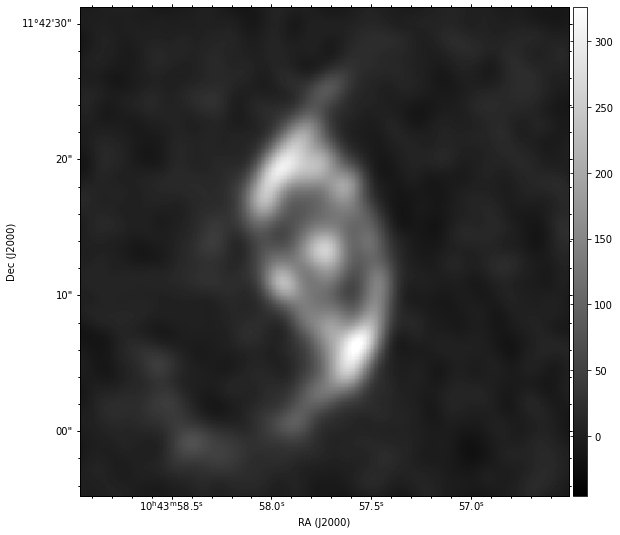

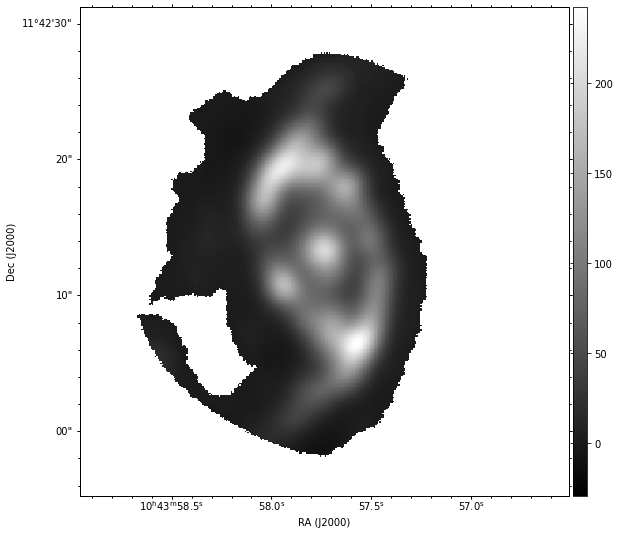

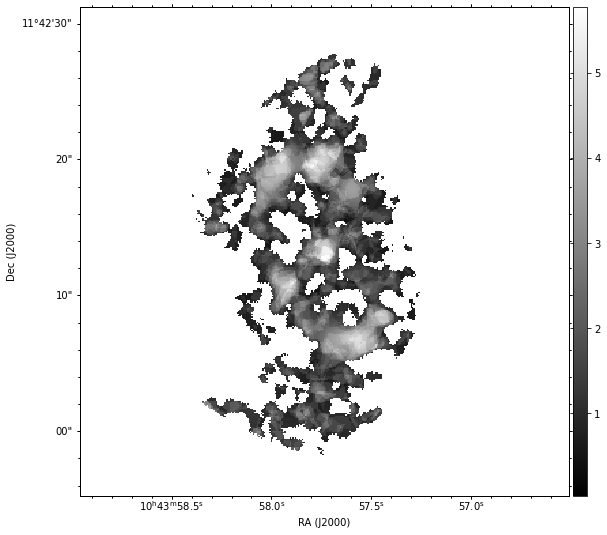

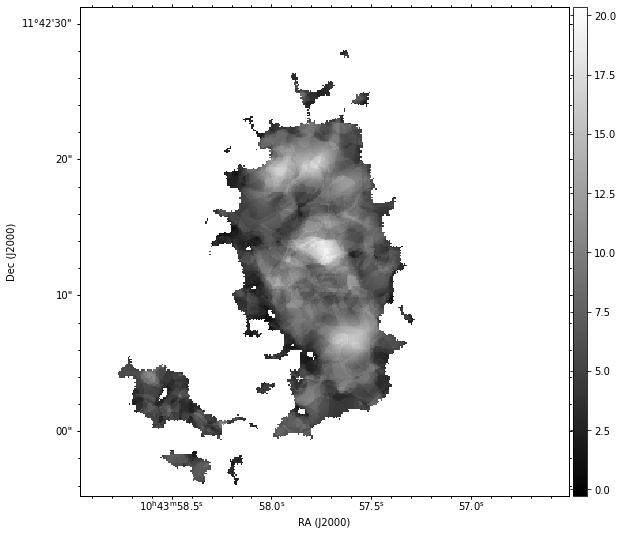

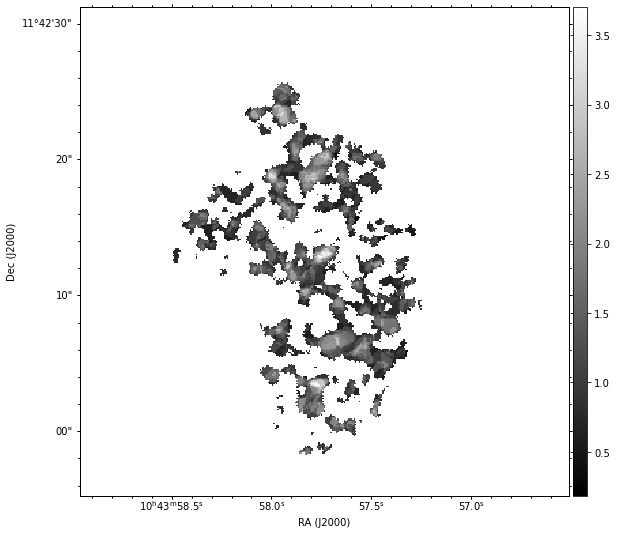

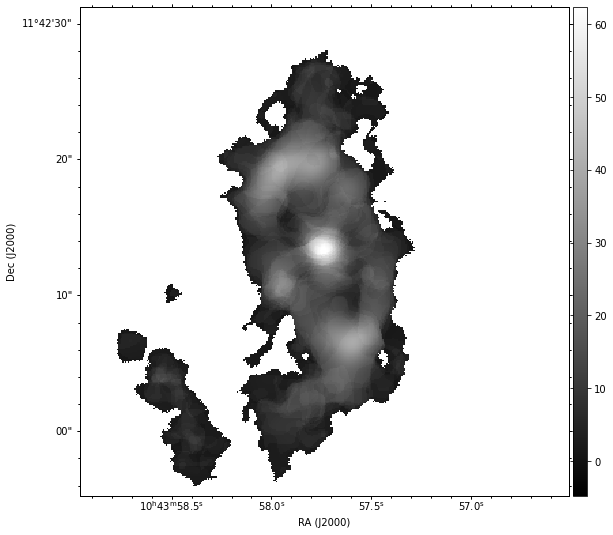

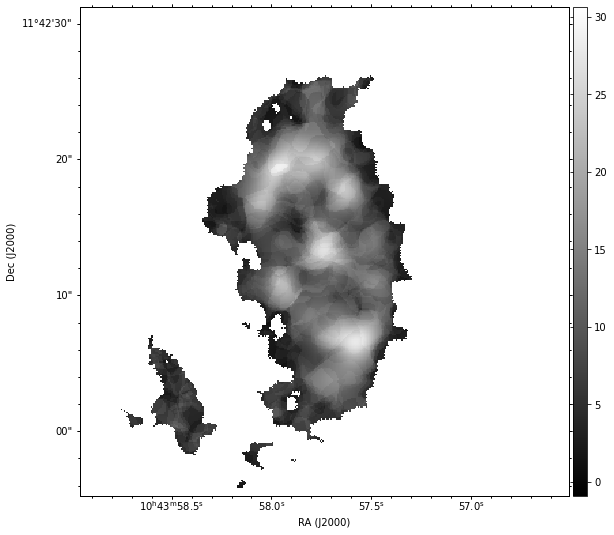

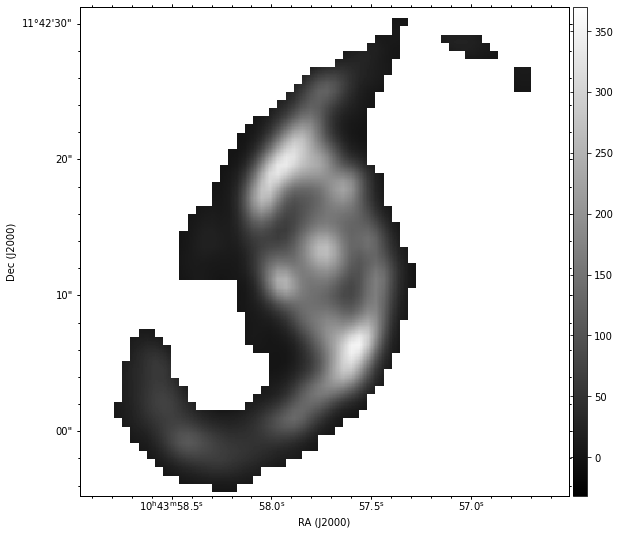

In [23]:
# creat moment_0 map 
cubef_maxbeam = SpectralCube.read(f_maxbeam)
#fileout = '_beamsmooth_moment_0_260929.fits'
fileout = '_beamsmooth_moment_0_masked.fits'

for f1 in cubefile_list_masked:
    if f1 != f_maxbeam:
        
        print(f"processing: {f1}")
        cubef1= SpectralCube.read(f1)
        
        #调用函数smooth 谱线到最大beam的谱线beam
        new_cubef1 = process_beams(cubef1, cubef_maxbeam)
        
        # check the new beam
        print('new_cubef1_beam =',new_cubef1.header['BEAM'])
        print('cubef_maxbeam =',cubef_maxbeam.header['BEAM'])
        print('new f1_RESTFRQ =',new_cubef1.header['RESTFRQ'])
        
        
        #moment_0 调用函数
        #moment_0_f1 = new_cubef1.with_spectral_unit(u.km/u.s).moment(order=0)
        moment_0_f1,moment_header_spatial = get_moment_map(new_cubef1)
        moment_0_f_maxbeam, moment_header_spatial = get_moment_map(cubef_maxbeam)
        
        
        # save the moment_0 file
        ti = f1.replace('.fits', '')
        moment_0_f1.write(ti+fileout,overwrite=True)
        moment_0_f_maxbeam.write(f_maxbeam.strip('.fits')+fileout,overwrite=True)
        
        
        # show the moment_0 file
        moment_0_f1.quicklook()
        
    else:
        print(f"跳过文件: {f1} (same to cubef_maxbeam)")
    
moment_0_f_maxbeam.quicklook()


In [11]:
!ls *beamsmooth_moment_0_masked.fits

M95_C3+7m_co32_co_prior_masked_cube_beamsmooth_moment_0_masked.fits
M95_C3+7m_hcop43_co_prior_masked_cube_beamsmooth_moment_0_masked.fits
M95_C5+C2_cs21_co_prior_masked_cube_beamsmooth_moment_0_masked.fits
M95_C5+C2_cs76_co_prior_masked_cube_beamsmooth_moment_0_masked.fits
M95_C5+C2_hcn10_co_prior_masked_cube_beamsmooth_moment_0_masked.fits
M95_C5+C2_hcop10_selfmask_masked_cube_beamsmooth_moment_0_masked.fits
ngc3351_12m+7m+tp_co10_selfmask_masked_cube_beamsmooth_moment_0_masked.fits


## moment_0 map of HCN(3-2) and HCO+(3-2)

In [13]:
ph='/Users/hjma/data/PHANGS-NGC3351/ALMAAchive/'
cubefile_list_32 = [
    ph+'ngc3351_7m_hcn32_pbcorr_trimmed_k.fits',
    ph+'ngc3351_7m_hcop32_pbcorr_trimmed_k.fits'
]

processing: /Users/hjma/data/PHANGS-NGC3351/ALMAAchive/ngc3351_7m_hcn32_pbcorr_trimmed_k.fits
beam= 0.001690754288327
INFO: Auto-setting vmin to -1.675e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.719e+00 [aplpy.core]
processing: /Users/hjma/data/PHANGS-NGC3351/ALMAAchive/ngc3351_7m_hcop32_pbcorr_trimmed_k.fits
beam= 0.00166959008723
INFO: Auto-setting vmin to -1.657e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.403e+00 [aplpy.core]


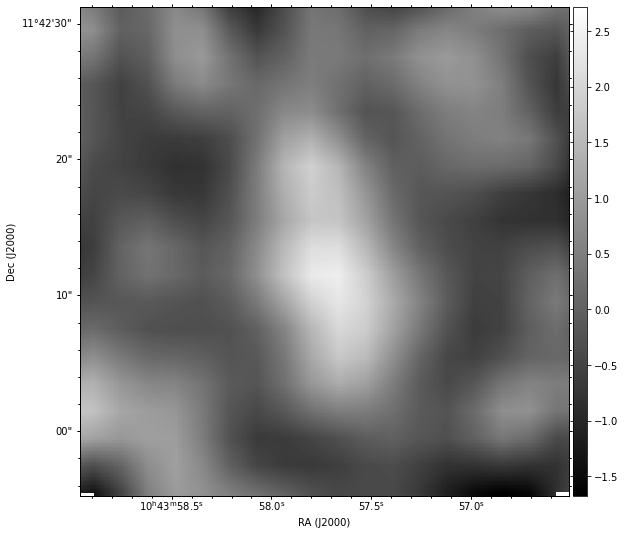

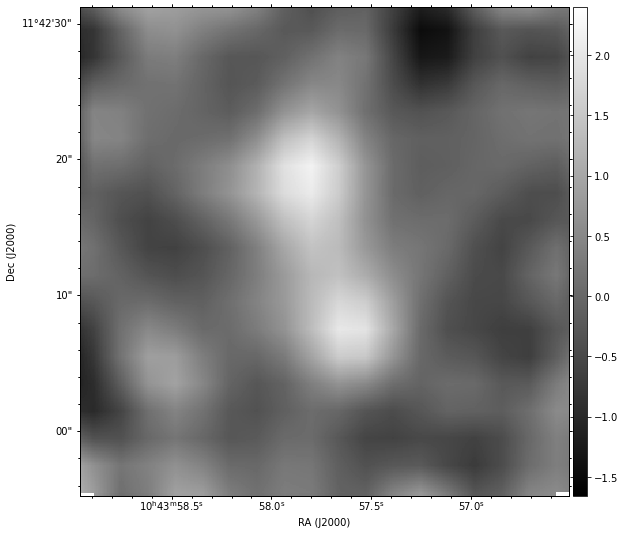

In [14]:
for cubef3_path in cubefile_list_32:    
    
    print(f"processing: {cubef3_path}")
    cubef3 = SpectralCube.read(cubef3_path)
    print('beam=',cubef3.header['BMAJ'])
    
    moment_0_f3, moment_header_spatial = get_moment_map(cubef3)


   # moment_0_f3 = cubef3.with_spectral_unit(u.km/u.s).moment(order=0)
    moment_header_spatial['RESTFRQ'] = cubef3.header['RESTFRQ']
    moment_header_spatial['BMAJ'] = cubef3.header['BMAJ']
    moment_header_spatial['BMIN'] = cubef3.header['BMIN']
    moment_header_spatial['BPA'] = cubef3.header['BPA']
    #moment_0_f3 = moment_0_f3.reproject(moment_header_spatial)
    
    moment_0_f3.quicklook()
    # get the file name 
    base_filename = os.path.basename(cubef3_path)
    tit = '_'.join(base_filename.strip('.fits').split('_')[:3])
    
    moment_0_f3.write(tit+fileout,overwrite=True)

In [25]:
!ls *_beamsmooth_moment_0_1208.fits

M95_C3+7m_co32_pbcorr_round_k_beamsmooth_moment_0_1208.fits
M95_C3+7m_cs76_pbcorr_round_k_beamsmooth_moment_0_1208.fits
M95_C3+7m_hcop43_pbcorr_round_k_beamsmooth_moment_0_1208.fits
M95_C5+C2_cs21_pbcorr_round_k_beamsmooth_moment_0_1208.fits
M95_C5+C2_hcn10_pbcorr_round_k_beamsmooth_moment_0_1208.fits
M95_C5+C2_hcop10_pbcorr_round_k_beamsmooth_moment_0_1208.fits
ngc3351_12m+7m+tp_co10_pbcorr_trimmed_k_beamsmooth_moment_0_1208.fits
ngc3351_12m+7m+tp_co21_beamsmooth_moment_0_1208.fits
ngc3351_7m_hcn32_beamsmooth_moment_0_1208.fits
ngc3351_7m_hcop32_beamsmooth_moment_0_1208.fits


In [16]:
23.16/212*1717425.77

187620.66430754715

In [17]:
7.95/212*1717425.77
3.86/212*1717425.77
24.21/212*1717425.77
22.32/212*1717425.77
7.72/212*1717425.77
7.72/212*1717425.77
3.91/212*1717425.77
12.86/212*1717425.77
7.95/212*1717425.77
9.00/212*1717425.77
12.86/212*1717425.77
10.23/212*1717425.77

82873.89446745283

In [21]:
# 系数列表
coeffs = [
    23.16,7.95, 3.86, 24.21, 22.32, 7.72, 7.72,
    3.91, 12.86, 7.95, 9.00, 12.86, 10.23
]
denominator = 212
base = 1717425.77

results = []
for c in coeffs:
    val = c / denominator * base
    ratio = c /denominator
    results.append(val)
    print(f"{c:>6} / {denominator} * {base} = {val:.6f}")
    print(f"{c:>6} / {denominator} = {ratio:.6f}")


 23.16 / 212 * 1717425.77 = 187620.664308
 23.16 / 212 = 0.109245
  7.95 / 212 * 1717425.77 = 64403.466375
  7.95 / 212 = 0.037500
  3.86 / 212 * 1717425.77 = 31270.110718
  3.86 / 212 = 0.018208
 24.21 / 212 * 1717425.77 = 196126.782508
 24.21 / 212 = 0.114198
 22.32 / 212 * 1717425.77 = 180815.769747
 22.32 / 212 = 0.105283
  7.72 / 212 * 1717425.77 = 62540.221436
  7.72 / 212 = 0.036415
  7.72 / 212 * 1717425.77 = 62540.221436
  7.72 / 212 = 0.036415
  3.91 / 212 * 1717425.77 = 31675.163966
  3.91 / 212 = 0.018443
 12.86 / 212 * 1717425.77 = 104179.695293
 12.86 / 212 = 0.060660
  7.95 / 212 * 1717425.77 = 64403.466375
  7.95 / 212 = 0.037500
   9.0 / 212 * 1717425.77 = 72909.584575
   9.0 / 212 = 0.042453
 12.86 / 212 * 1717425.77 = 104179.695293
 12.86 / 212 = 0.060660
 10.23 / 212 * 1717425.77 = 82873.894467
 10.23 / 212 = 0.048255
